# Stage 6: Central Belt Inference Siting — Synthesis Notebook

Companion to `STAGE6_SYNTHESIS.md`. This notebook reproduces every headline
figure in that document from the four underlying modules — nothing here is
retyped from memory. Every section ends with an executable `assert` checking
the number the chart is built on, matching this project's numbers discipline.

**Modules:** `duos_central_belt.py`, `tnuos_central_belt.py`,
`capex_central_belt.py`, `inference_load_central_belt.py` — all in `../scripts/`.

**Companion document:** `../STAGE6_SYNTHESIS.md` for the full narrative,
Assumptions Ledger, and policy framing behind each figure below.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "scripts"))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date

import duos_central_belt as duos
import tnuos_central_belt as tnuos
import inference_load_central_belt as load
import capex_central_belt as capex

# House style, consistent across every Stage 6 figure
COLOR_TRAINING = "#8C9BA5"
COLOR_INFERENCE = "#2A6F97"
COLOR_ACCENT = "#D1495B"
COLOR_GOOD = "#4C956C"
COLOR_NEUTRAL = "#6C757D"

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#333333", "figure.facecolor": "white",
    "axes.facecolor": "white", "savefig.facecolor": "white",
})


## Finding 1: DUoS Value Runs the Opposite Direction from Stage 5

Stage 5's 100MW training site sat at 132kV/EHV in Northern Scotland. Stage 6's
5MW inference site sits at HV in the Central Belt. Same mechanism (DUoS
Red-Green arbitrage), opposite result: value scales *down* with voltage, not
with site size.


In [2]:
comparison = duos.compare_to_stage5_training_site()
stage5_diff = comparison["stage5_shepd_132kv_ehv_differential_gbp_mwh"]
stage6_diff = comparison["stage6_spd_hv_differential_gbp_mwh"]
ratio = comparison["ratio"]

assert abs(ratio - 27.6) < 0.5, f"Ratio check failed: {ratio}"
print(f"Stage 5 (132kV/EHV): £{stage5_diff}/MWh")
print(f"Stage 6 (HV):        £{stage6_diff}/MWh")
print(f"Ratio: {ratio}x")


Stage 5 (132kV/EHV): £1.58/MWh
Stage 6 (HV):        £43.67/MWh
Ratio: 27.6x


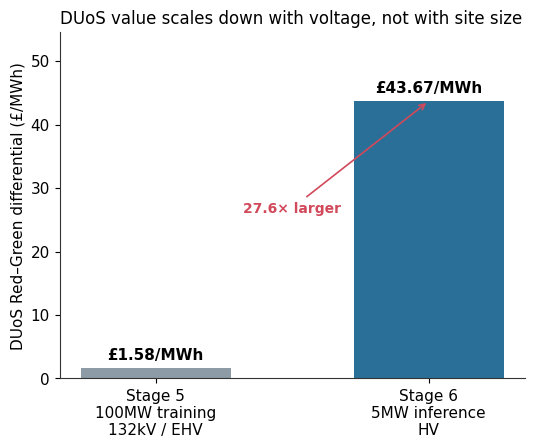

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(
    ["Stage 5\n100MW training\n132kV / EHV", "Stage 6\n5MW inference\nHV"],
    [stage5_diff, stage6_diff], color=[COLOR_TRAINING, COLOR_INFERENCE], width=0.55,
)
for bar, val in zip(bars, [stage5_diff, stage6_diff]):
    ax.annotate(f"£{val:.2f}/MWh", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 6), ha="center", fontweight="bold")
ax.annotate("27.6\u00d7 larger", xy=(1, stage6_diff), xytext=(0.5, stage6_diff * 0.6),
            fontsize=10, color=COLOR_ACCENT, fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="->", color=COLOR_ACCENT, lw=1.2))
ax.set_ylabel("DUoS Red\u2013Green differential (£/MWh)")
ax.set_title("DUoS value scales down with voltage, not with site size", fontsize=12, loc="left")
ax.set_ylim(0, stage6_diff * 1.25)
plt.show()


### Realising this value: the load profile and battery coverage check

A tariff differential isn't a realised value until something can actually
capture it. This is where the inference load profile earns its place — built
as a diurnal curve informed by measured generative-AI inference power data,
not a scaled-down copy of Stage 5's training-spike shape (inference has no
scheduled job starts to spike around).


In [4]:
target = date(2026, 8, 5)
site_mw = 5.0
battery_mw = site_mw * 0.5

profile = load.generate_inference_load_profile(target, site_capacity_mw=site_mw)
coverage = load.check_battery_coverage(profile, battery_mw)

assert coverage["coverage_confirmed"], "Battery coverage check failed"
print(f"Red-band periods checked: {coverage['n_red_band_periods']}")
print(f"Shortfall periods: {coverage['n_shortfall_periods']}")
print(f"Minimum load in Red band: {coverage['min_load_in_red_band_mw']}MW vs {battery_mw}MW battery")


Red-band periods checked: 6
Shortfall periods: 0
Minimum load in Red band: 4.882MW vs 2.5MW battery


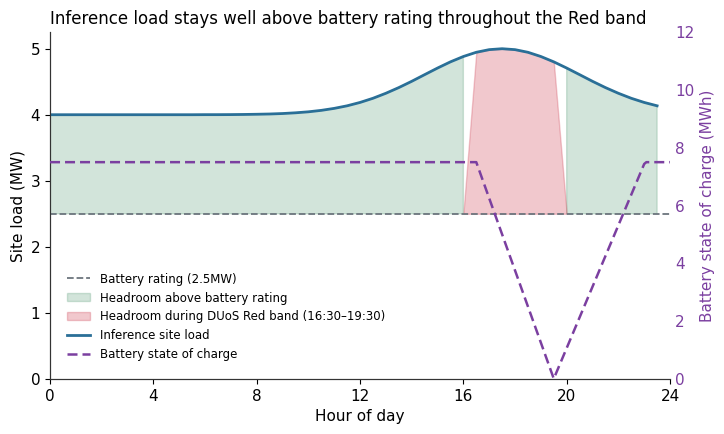

In [5]:
import numpy as np

hours = [p.period_start.hour + p.period_start.minute / 60 for p in profile]
loads = [p.load_mw for p in profile]
hours_arr = np.array(hours)
loads_arr = np.array(loads)
in_red_band = (hours_arr >= 16.5) & (hours_arr <= 19.5)

# Battery state of charge — a new, explicit assumption: charge immediately
# once the Red band ends, at full rate. Usable SoC range 0-7.5MWh, matching
# required_energy_capacity_mwh(). Not previously specified anywhere in the
# modules — added here because it's what makes the charge/discharge cycle
# visible rather than something to hold in your head.
soc_max_mwh = battery_mw * 3.0
red_start, red_end = 16.5, 19.5
charge_end = red_end + soc_max_mwh / (battery_mw * 0.85)  # 0.85 = Stage 3's RTE figure

soc_hours = np.linspace(0, 24, 289)
soc_mwh = np.where(
    soc_hours < red_start, soc_max_mwh,
    np.where(
        soc_hours < red_end, soc_max_mwh - battery_mw * (soc_hours - red_start),
        np.where(
            soc_hours < charge_end, (battery_mw * 0.85) * (soc_hours - red_end),
            soc_max_mwh
        )
    )
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(battery_mw, color=COLOR_NEUTRAL, ls="--", lw=1.3, zorder=3,
           label=f"Battery rating ({battery_mw}MW)")
ax.fill_between(hours, battery_mw, loads, where=~in_red_band, color=COLOR_GOOD,
                 alpha=0.25, interpolate=True, label="Headroom above battery rating")
ax.fill_between(hours, battery_mw, loads, where=in_red_band, color=COLOR_ACCENT,
                 alpha=0.30, interpolate=True, label="Headroom during DUoS Red band (16:30\u201319:30)")
ax.plot(hours, loads, color=COLOR_INFERENCE, lw=2, zorder=4, label="Inference site load")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.set_ylim(0, max(loads) * 1.05)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Site load (MW)")

ax2 = ax.twinx()
ax2.plot(soc_hours, soc_mwh, color="#7B3FA0", lw=1.8, ls=(0, (4, 2)),
         zorder=5, label="Battery state of charge")
ax2.set_ylabel("Battery state of charge (MWh)", color="#7B3FA0")
ax2.set_ylim(0, soc_max_mwh * 1.6)
ax2.tick_params(axis="y", colors="#7B3FA0", length=0)
ax2.spines["right"].set_color("#7B3FA0")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="lower left",
          bbox_to_anchor=(0.01, 0.02), ncol=1, frameon=True, framealpha=0.9,
          edgecolor="none", fontsize=8.5)

ax.set_title("Inference load stays well above battery rating throughout the Red band", fontsize=12, loc="left")
plt.show()


**Note on the state-of-charge curve above:** the dispatch rule (charge
immediately once Red band ends, at full 2.5MW rate) is a new, explicit
assumption introduced for this visualisation — nothing elsewhere in the
Stage 6 modules previously specified *when* during the Green period charging
happens, only that it should. The charging duration (~3.53 hours) isn't a
separate assumption though — it falls directly out of numbers already
established: 7.5MWh usable capacity, 85% round-trip efficiency, 2.5MW rate.


### Gross vs net: charging discipline, not battery losses, is what matters

The naive calculation (battery MW × Red-band hours × differential) gives a
**gross** figure. The **net** figure accounts for round-trip efficiency and
the cost of the charging energy required to deliver that discharge — and
where that charging happens turns out to matter far more than the round-trip
efficiency loss itself.


In [6]:
gross_result = load.realised_annual_duos_value(battery_mw, stage6_diff)
gross = gross_result["annual_value_gbp"]
red_rate = 43.77

scenarios = [("Green\n£0.10/MWh", 0.10), ("Amber\n£3.22/MWh", 3.22), ("Red\n£43.77/MWh", 43.77)]
net_values = []
for label, charge_rate in scenarios:
    net = load.net_annual_duos_value(battery_mw, red_rate, charge_rate)
    net_values.append(net["net_annual_gbp"])
    print(f"Charging in {label.split(chr(10))[0]}: £{net['net_annual_gbp']:,.0f}/year "
          f"({net['net_annual_gbp']/gross*100:.1f}% of gross)")

assert net_values[0] > 0 and net_values[2] < 0, "Charging-period sensitivity check failed"


Charging in Green: £119,498/year (100.0% of gross)
Charging in Amber: £109,450/year (91.6% of gross)
Charging in Red: £-21,145/year (-17.7% of gross)


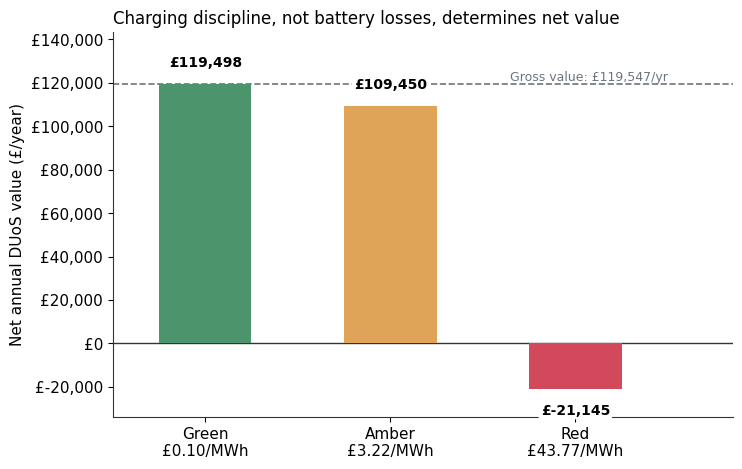

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = [s[0] for s in scenarios]
colors_bar = [COLOR_GOOD, "#E0A458", COLOR_ACCENT]
bars = ax.bar(labels, net_values, color=colors_bar, width=0.5, zorder=3)
ax.axhline(0, color="#333333", lw=1, zorder=2)
ax.axhline(gross, color=COLOR_NEUTRAL, ls="--", lw=1.2, zorder=1)
ax.annotate(f"Gross value: £{gross:,.0f}/yr", xy=(2.5, gross), xytext=(2.5, gross),
            fontsize=9, color=COLOR_NEUTRAL, ha="right", va="bottom")
for bar, val in zip(bars, net_values):
    va = "bottom" if val >= 0 else "top"
    offset = 10 if val >= 0 else -10
    ax.annotate(f"£{val:,.0f}", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, offset), ha="center", va=va,
                fontsize=10, fontweight="bold", zorder=5,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none"))
ax.set_ylabel("Net annual DUoS value (£/year)")
ax.set_title("Charging discipline, not battery losses, determines net value", fontsize=12, loc="left")
ax.set_xlim(-0.5, 2.85); ax.set_ylim(min(net_values) * 1.6, gross * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.show()


## Finding 2: TNUoS — A 5MW Site Sits Unambiguously in the Top HV Band

Post-2023 TCR, the TNUoS demand residual is non-locational — banded purely by
capacity, the same charge nationwide regardless of zone. A 5MW site converts
to roughly 5,263kVA at a 0.95 power factor, which places it firmly in the top
HV band.


In [8]:
assigned = tnuos.assign_band(site_mw)
assert assigned.band_name == "HV4", f"Band assignment check failed: {assigned.band_name}"

annual = tnuos.annual_cost_gbp(assigned)
print(f"Site: {site_mw}MW -> assigned band: {assigned.band_name}")
print(f"Annual TNUoS residual: £{annual:,.0f}/year")


Site: 5.0MW -> assigned band: HV4
Annual TNUoS residual: £193,053/year


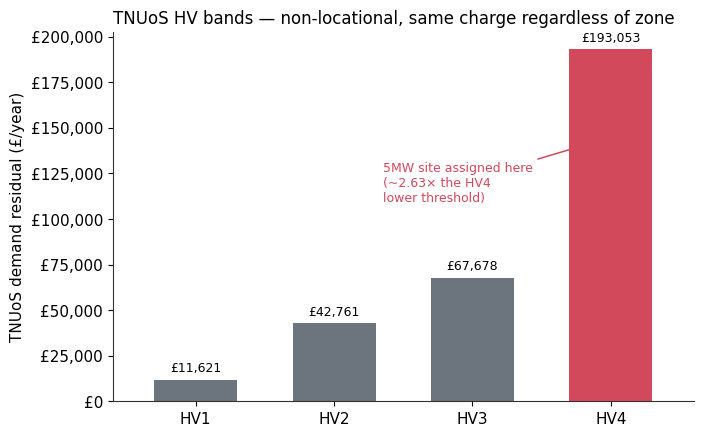

In [9]:
band_names = [b.band_name for b in tnuos.HV_BANDS]
band_annual = [tnuos.annual_cost_gbp(b) for b in tnuos.HV_BANDS]
colors = [COLOR_ACCENT if b.band_name == assigned.band_name else COLOR_NEUTRAL for b in tnuos.HV_BANDS]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(band_names, band_annual, color=colors, width=0.6)
for bar, val in zip(bars, band_annual):
    ax.annotate(f"£{val:,.0f}", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
ax.annotate("5MW site assigned here\n(~2.63\u00d7 the HV4\nlower threshold)",
            xy=(3, band_annual[3] * 0.75), xytext=(1.35, band_annual[3] * 0.62),
            fontsize=9, color=COLOR_ACCENT, ha="left", va="center",
            arrowprops=dict(arrowstyle="->", color=COLOR_ACCENT, lw=1.1))
ax.set_ylabel("TNUoS demand residual (£/year)")
ax.set_title("TNUoS HV bands \u2014 non-locational, same charge regardless of zone", fontsize=12, loc="left")
ax.set_xlim(-0.6, 3.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.show()


### Is the band-step saving actually available to this site?

The tariff table alone says stepping down from HV4 to a lower band would
save real money. That's true of the *table* — it doesn't check whether the
step is *reachable*, which depends on the site's own minimum load, not the
tariff rates. Worth checking directly rather than assuming.


In [10]:
feasibility = tnuos.feasible_band_step(assigned, site_min_load_mw=4.0)
for check in feasibility["band_checks"]:
    status = "REACHABLE" if check["reachable"] else f"NOT REACHABLE (short by {check['shortfall_mw']}MW)"
    print(f"{check['band']}: ceiling {check['ceiling_mw']}MW -> {status}")

assert not feasibility["any_band_step_feasible"], \
    "Expected no band step to be feasible for this site's load profile"
print(f"\nAny band-step feasible for this site: {feasibility['any_band_step_feasible']}")


HV1: ceiling 0.47MW -> NOT REACHABLE (short by 3.52MW)
HV2: ceiling 1.04MW -> NOT REACHABLE (short by 2.96MW)
HV3: ceiling 1.9MW -> NOT REACHABLE (short by 2.1MW)

Any band-step feasible for this site: False


**No lower band is reachable.** HV3's ceiling is roughly 1.90MW; this site's
own minimum load — its quietest overnight hour, from Finding 1's load
profile — never drops below 4.0MW. HV2 and HV1 are further out of reach
again. HV4 isn't a starting point with room to improve for this site; it's
the only band this site's real load profile can ever occupy.

An earlier version of this analysis reported £125,375\u2013£181,432/year as
available savings, computed straight from the tariff table without this
check. That was a real error, not a rounding difference \u2014 caught in
conversation, not by either prior review pass. The mechanism itself is
genuine (it's the same step-function logic behind Stage 5's £1.8M EHV
finding), and would apply to a site with more headroom between its floor
demand and a lower band's ceiling. This specific archetype, defined by a
narrow trough-to-peak range, structurally cannot use it \u2014 the same
narrow range that makes Finding 1's DUoS mechanism unusually reliable cuts
the other way here.


**Capture route caveat** (see `STAGE6_SYNTHESIS.md` Finding 2 for the full
chain, and note this is now moot for this specific site given the finding
above \u2014 preserved because the mechanism is real for the archetype in
general): TNUoS is billed to the site's electricity Supplier, not the site
directly — the saving reaches the site through its supply contract. Two of
three links in that chain are sourced; one (whether DNO-agreed MIC is
specifically what determines the TNUoS band) is inferred, not confirmed.
Status: **PARTIALLY GROUNDED**, not GROUNDED — flagged explicitly rather than
overstated.


## Finding 3: Fee Proportionality, Corrected

The original version of this finding used the wrong site (Asanti Livingston,
5MW — below the fee's own 40MW threshold) and the wrong capex source
(international brownfield literature). Corrected: DataVita DV1 (40MW, a real
site sitting exactly at the threshold) against Ofgem's *own* published GB
queue capex data.


In [11]:
benchmark = capex.OFGEM_DNO_CAPEX_BY_SIZE["Medium (10-50MW)"]
result = capex.proportionality_check(40.0, benchmark)

assert 1.5 < result["fee_pct_of_capex_mean_low"] < 3.0, "Proportionality check out of expected range"
print(f"Benchmark: {result['benchmark']} (n={result['benchmark_n_projects']})")
print(f"Fee as % of capex (median): {result['fee_pct_of_capex_median_low']}% - {result['fee_pct_of_capex_median_high']}%")
print(f"Fee as % of capex (mean):   {result['fee_pct_of_capex_mean_low']}% - {result['fee_pct_of_capex_mean_high']}%")
print(f"Ofgem's stated target: {result['ofgem_target_range_pct'][0]}% - {result['ofgem_target_range_pct'][1]}%")

# Invariance check: does it matter whether DV1 is treated as 40MW (IT load)
# or ~47.2MW (estimated grid capacity at DV1's own 1.18 PUE)? Checked, not assumed.
result_47 = capex.proportionality_check(47.2, benchmark)
assert abs(result["fee_pct_of_capex_mean_low"] - result_47["fee_pct_of_capex_mean_low"]) < 0.001, \
    "Ratio should be invariant to site_mw - ledger claim would be wrong if this fails"
print(f"\nInvariance check: ratio at 40MW = {result['fee_pct_of_capex_mean_low']}%, "
      f"at 47.2MW = {result_47['fee_pct_of_capex_mean_low']}% (identical, as expected)")


Benchmark: Medium (10-50MW) (n=8)
Fee as % of capex (median): 2.36% - 7.09%
Fee as % of capex (mean):   1.75% - 5.26%
Ofgem's stated target: 2.5% - 7.5%

Invariance check: ratio at 40MW = 1.75%, at 47.2MW = 1.75% (identical, as expected)


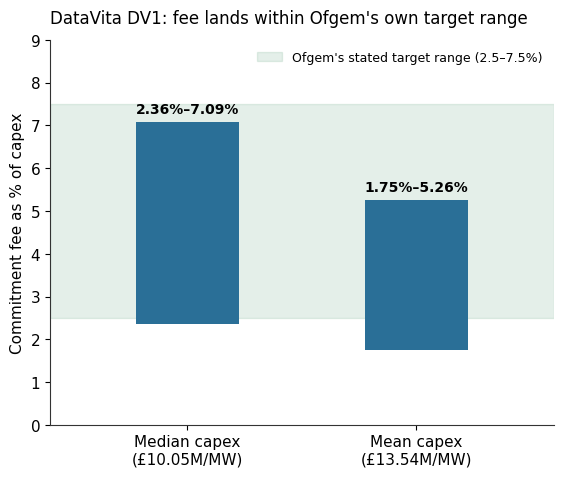

In [12]:
ofgem_low, ofgem_high = 2.5, 7.5
categories = [f"Median capex\n(£{benchmark.median_gbp_per_mw/1e6:.2f}M/MW)",
              f"Mean capex\n(£{benchmark.mean_gbp_per_mw/1e6:.2f}M/MW)"]
low_vals = [result["fee_pct_of_capex_median_low"], result["fee_pct_of_capex_mean_low"]]
high_vals = [result["fee_pct_of_capex_median_high"], result["fee_pct_of_capex_mean_high"]]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.axhspan(ofgem_low, ofgem_high, color=COLOR_GOOD, alpha=0.15, zorder=1,
           label="Ofgem's stated target range (2.5\u20137.5%)")
x_pos = [0, 1]
for x, lo, hi in zip(x_pos, low_vals, high_vals):
    ax.bar(x, hi - lo, bottom=lo, width=0.45, color=COLOR_INFERENCE, zorder=3)
    ax.annotate(f"{lo:.2f}%\u2013{hi:.2f}%", (x, hi), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x_pos); ax.set_xticklabels(categories)
ax.set_xlim(-0.6, 1.6); ax.set_ylim(0, 9)
ax.set_ylabel("Commitment fee as % of capex")
ax.set_title("DataVita DV1: fee lands within Ofgem's own target range", fontsize=12, loc="left", pad=12)
ax.legend(loc="upper right", frameon=False, fontsize=9)
plt.show()


**Why no comparison to the original, pre-correction estimate:** that number
(13.7%, from the wrong site anchor and the wrong capex source) lives in
`STAGE6_SYNTHESIS.md`'s Finding 3, told properly in prose with the reasoning
for why it was wrong. A chart can travel without its caption attached — a
stray data point at 13.7% with no surrounding context is easy to
misread as a live concern rather than a superseded one. This chart shows
only what's actually true now.

**Worth noting plainly, not glossed over:** both bars dip slightly *below*
the target range at their low end (the mean-capex bar's floor, 1.75%, sits
visibly under Ofgem's 2.5% minimum) even as they stay comfortably clear of
the top. The honest finding is "spans the range, dipping under at the low
end" — not "sits neatly inside it."


## Finding 4: The Milestone Argument — No Chart, and That's the Right Call

Finding 4 (Curate vs Connect Operate, the Flex Technical Taskforce, the
constraint-direction evidence Ofgem has already independently arrived at) is
a policy-structure argument, not a quantified relationship. Forcing it into a
chart would manufacture false quantitative precision around a qualitative
regulatory-design point. See `STAGE6_SYNTHESIS.md` Finding 4 for the full
argument — it belongs in prose, not a figure.


## Summary

| Finding | Headline number | Chart |
|---|---|---|
| 1. DUoS | 27.6\u00d7 differential; £119,547/yr gross, £119,498/yr net (Green charging) | Figures 1, 2, 4 above |
| 2. TNUoS | HV4 band, £193,053/yr, ~2.63\u00d7 the threshold. No band-step saving available (checked, not assumed) | Figure 3 above |
| 3. Fee proportionality | 1.75%\u20137.09% \u2014 spans Ofgem's own 2.5\u20137.5% target | Figure 5 above |
| 4. Milestones | Curate vs Connect Operate coordination gap \u2014 qualitative | Prose only, `STAGE6_SYNTHESIS.md` |

Every number above was computed in this notebook by calling the underlying
modules directly — none were retyped. Re-running this notebook top to bottom
should reproduce every figure and pass every assertion.
